# Глобальное сравнение методов восстановления спектров

Обновлённая версия ноутбука (бывший `34`), переписанная под текущий публичный
API `bssunfold`:

- вместо устаревшего `bsu.Unfolder` используется `Detector.unfold_*` с
  актуальными именами параметров (`max_iterations`, `k`, `epsilon`,
  `sigma_factor`, `solver`);
- импорт `cosine_similarity` из `sklearn.metrics` заменён на метрики, которые
  считает `det.compare` (в т.ч. `dose_difference_percent` — разница эффективной
  дозы H*(10));
- прогон методов реализован через `benchmark_unfold_methods` из
  `bssunfold.utils.comparison` (протестированный код).

## Цели
1. Подбор оптимальных параметров для каждого метода через Grid Search.
2. Выбор лучшего метода по композитному скорингу (ΔDose 40%, невязка 30%,
   Cosine 20%, R² 10%).
3. Сравнение на различных датасетах (демо на малом наборе; полный 251 спектр —
   опционально).
4. Тестирование на разных функциях чувствительности (разные детекторы).

> Для быстрого старта демо использует 3 спектра и 5 методов. Увеличьте
> `TEST_SPECTRA` / `FULL_METHODS_GRID` для полного бенчмарка.

In [1]:
import ast
import json
import warnings
from datetime import datetime
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

import bssunfold as bsu
from bssunfold import Detector, RF_LANL
from bssunfold.utils.comparison import (
    benchmark_unfold_methods,
    DEFAULT_UNFOLD_BENCHMARK_METHODS,
)
from bssunfold.core.dose_calculation import calculate_dose_rates

print(f"bssunfold version: {bsu.__version__}")

bssunfold version: 0.17.2


## Загрузка тестовых данных

In [2]:
# Эталонные спектры IAEA (E_MeV - индекс, далее - колонки спектров)
iaea_df = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv',
    index_col=0,
)
try:
    detectors_df = pd.read_csv('../tests/IAEA_Compendium_dataset.csv')
    print(f"Detectors dataset loaded: {detectors_df.shape}")
except FileNotFoundError:
    detectors_df = None

det = Detector(RF_LANL)
print(f"Detector: {len(det.E_MeV)} energy bins, {len(det.detector_names)} spheres")
print(f"Загружено спектров: {len(iaea_df.columns)}")
print(f"Диапазон энергий: {iaea_df.index.min():.2e} - {iaea_df.index.max():.2e} MeV")

Detectors dataset loaded: (251, 115)
Detector: 60 energy bins, 11 spheres
Загружено спектров: 20
Диапазон энергий: 1.00e-09 - 6.31e+02 MeV


## Подготовка эталонных спектров

Спектры из базы IAEA могут быть на сетке, отличной от сетки детектора.
Ресемплируем каждый эталон на `det.E_MeV`, чтобы `det.compare` корректно
считал метрики (требуется совпадение числа бинов).

In [3]:
def get_reference_spectrum(df, name, det):
    src_e = df.index.values.astype(float)
    src_phi = df[name].values.astype(float)
    # Ресемплинг на сетку детектора
    phi = np.interp(det.E_MeV, src_e, src_phi)
    return {'E_MeV': det.E_MeV, 'Phi': phi}

## Метрики и функция Grid Search

Используем `benchmark_unfold_methods` как движок прогона. `det.compare`
возвращает `dose_difference_percent` (ΔH*(10)), `cosine_similarity`, `r2_score`
и `root_mean_squared_error` (RMSE используется как прокси нормы невязки).

Композитный скор: `-ΔDose*0.4 - RMSE*0.3 + Cosine*0.2 + R²*0.1`
(чем выше — тем лучше; ошибки учитываются со знаком минус).

In [4]:
METRICS = [
    'r2_score',
    'cosine_similarity',
    'dose_difference_percent',
    'root_mean_squared_error',
]


def _composite(row):
    dose = row.get('dose_difference_percent', np.nan)
    rmse = row.get('root_mean_squared_error', np.nan)
    cos = row.get('cosine_similarity', np.nan)
    r2 = row.get('r2_score', np.nan)
    if any(pd.isna(v) for v in (dose, rmse, cos, r2)):
        return np.nan
    # weights: dose 40%, residual(RMSE) 30%, cosine 20%, r2 10%
    return -dose * 0.4 - rmse * 0.3 + cos * 0.2 + r2 * 0.1


def run_grid_search(det, refs, methods_config, metrics=METRICS, progress=False):
    """Run the benchmark and append a composite score per run."""
    res = benchmark_unfold_methods(
        det, refs, methods=methods_config, metrics=metrics, progress=progress
    )
    df = res.results.copy()
    df['composite_score'] = df.apply(_composite, axis=1)
    return df

## Конфигурация методов (Grid Search)

In [5]:
# Curated demo registry with CURRENT-API parameter names.
DEMO_METHODS = {
    'mlem':      {'method': 'unfold_mlem',      'params': [{'max_iterations': 10}, {'max_iterations': 50}]},
    'tsvd':      {'method': 'unfold_tsvd',      'params': [{'k': 3}, {'k': 7}]},
    'landweber': {'method': 'unfold_landweber', 'params': [{'max_iterations': 10}, {'max_iterations': 50}]},
    'maxed':     {'method': 'unfold_maxed',     'params': [{'sigma_factor': 0.05}]},
    'cvxpy':     {'method': 'unfold_cvxpy',     'params': [{'solver': 'ECOS'}]},
}

# Full registry (~17 methods) for an exhaustive run - see optional cell below.
FULL_METHODS_GRID = DEFAULT_UNFOLD_BENCHMARK_METHODS

print(f"Demo methods: {len(DEMO_METHODS)} | Full methods: {len(FULL_METHODS_GRID)}")

Demo methods: 5 | Full methods: 17


## Запуск на малом датасете (реальный прогон)

По умолчанию — 3 спектра и 5 методов (быстро). Для полного бенчмарка
увеличьте `TEST_SPECTRA` и используйте `FULL_METHODS_GRID`.

In [6]:
TEST_SPECTRA = iaea_df.columns[:3].tolist()
print(f"Тестируем на {len(TEST_SPECTRA)} спектрах")

refs = {name: get_reference_spectrum(iaea_df, name, det) for name in TEST_SPECTRA}

results_demo = run_grid_search(det, refs, DEMO_METHODS, METRICS, progress=True)
print(f"\nВсего прогонов: {len(results_demo)}")
print(results_demo[['method', 'params', 'spectrum', 'success',
                    'r2_score', 'cosine_similarity',
                    'dose_difference_percent', 'composite_score']].to_string())

Тестируем на 3 спектрах


  ISO_ref_Cf252/mlem: ok (0.50s)
  ISO_ref_Cf252/mlem: ok (0.00s)
  ISO_ref_Cf252/tsvd: ok (0.00s)
  ISO_ref_Cf252/tsvd: ok (0.00s)
  ISO_ref_Cf252/landweber: ok (0.00s)
  ISO_ref_Cf252/landweber: ok (0.00s)
  ISO_ref_Cf252/maxed: ok (0.15s)


  ISO_ref_Cf252/cvxpy: ok (0.12s)
  ISO_ref_Cf252_2/mlem: ok (0.00s)
  ISO_ref_Cf252_2/mlem: ok (0.00s)
  ISO_ref_Cf252_2/tsvd: ok (0.00s)
  ISO_ref_Cf252_2/tsvd: ok (0.00s)
  ISO_ref_Cf252_2/landweber: ok (0.00s)
  ISO_ref_Cf252_2/landweber: ok (0.00s)
  ISO_ref_Cf252_2/maxed: ok (0.15s)
  ISO_ref_Cf252_2/cvxpy: ok (0.00s)
  ISO_ref_AmBe/mlem: ok (0.00s)
  ISO_ref_AmBe/mlem: ok (0.00s)
  ISO_ref_AmBe/tsvd: ok (0.00s)
  ISO_ref_AmBe/tsvd: ok (0.00s)
  ISO_ref_AmBe/landweber: ok (0.00s)
  ISO_ref_AmBe/landweber: ok (0.00s)


  ISO_ref_AmBe/maxed: ok (0.16s)
  ISO_ref_AmBe/cvxpy: ok (0.00s)

Всего прогонов: 24
       method                  params         spectrum  success     r2_score  cosine_similarity  dose_difference_percent  composite_score
0        mlem  {'max_iterations': 10}    ISO_ref_Cf252     True   -82.136500           0.821954               810.316643      -332.452334
1        mlem  {'max_iterations': 50}    ISO_ref_Cf252     True  -209.790730           0.500723               808.729549      -344.810893
2        tsvd                {'k': 3}    ISO_ref_Cf252     True     0.978038           0.990259                 6.546517        -2.327244
3        tsvd                {'k': 7}    ISO_ref_Cf252     True     0.978038           0.990259                 6.546517        -2.327244
4   landweber  {'max_iterations': 10}    ISO_ref_Cf252     True     0.653180           0.841988                 8.343323        -3.121467
5   landweber  {'max_iterations': 50}    ISO_ref_Cf252     True     0.839257          

## Визуализация результатов

Графики сохранены в methods_comparison_summary.png


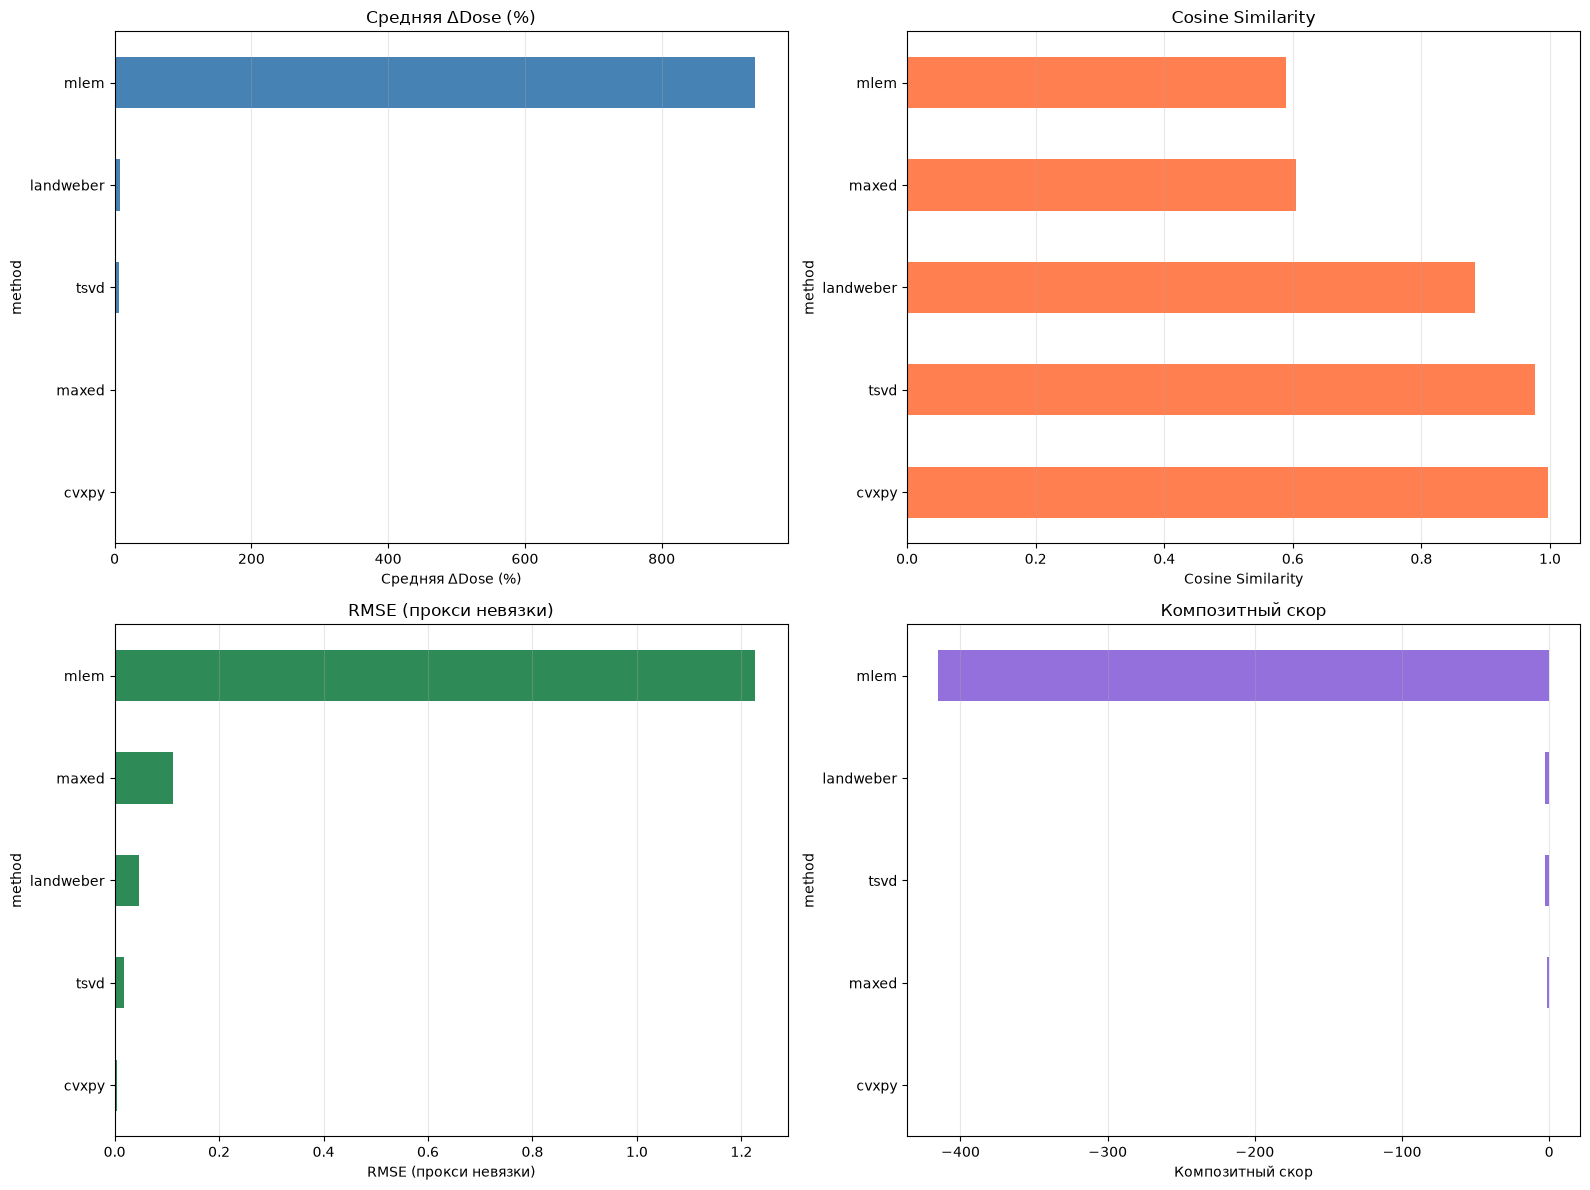

In [7]:
def plot_comparison_charts(results_df):
    agg = results_df.groupby('method').agg({
        'dose_difference_percent': 'mean',
        'cosine_similarity': 'mean',
        'root_mean_squared_error': 'mean',
        'r2_score': 'mean',
        'composite_score': 'mean',
    })
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    specs = [
        ('dose_difference_percent', 'Средняя ΔDose (%)', 'steelblue', True),
        ('cosine_similarity', 'Cosine Similarity', 'coral', False),
        ('root_mean_squared_error', 'RMSE (прокси невязки)', 'seagreen', True),
        ('composite_score', 'Композитный скор', 'mediumpurple', False),
    ]
    for ax, (col, title, color, asc) in zip(axes.flat, specs):
        data = agg[col].sort_values(ascending=asc)
        data.plot(kind='barh', ax=ax, color=color)
        ax.set_xlabel(title)
        ax.set_title(title)
        ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('methods_comparison_summary.png', dpi=300, bbox_inches='tight')
    print("Графики сохранены в methods_comparison_summary.png")
    plt.show()

plot_comparison_charts(results_demo)

## Анализ лучших параметров для каждого метода

In [8]:
def analyze_best_parameters(results_df):
    print("\n" + "="*60)
    print("АНАЛИЗ ЛУЧШИХ ПАРАМЕТРОВ")
    print("="*60)
    for method in results_df['method'].unique():
        m = results_df[results_df['method'] == method]
        best = m.loc[m['composite_score'].idxmax()]
        print(f"\n{method}:")
        print(f"  Лучшие параметры: {best['params']}")
        print(f"  Composite score: {best['composite_score']:.3f}")
        print(f"  ΔDose: {best['dose_difference_percent']:.2f}%, "
              f"CosSim: {best['cosine_similarity']:.3f}, "
              f"RMSE: {best['root_mean_squared_error']:.3f}, R²: {best['r2_score']:.3f}")

analyze_best_parameters(results_demo)


АНАЛИЗ ЛУЧШИХ ПАРАМЕТРОВ

mlem:
  Лучшие параметры: {'max_iterations': 10}
  Composite score: -303.406
  ΔDose: 738.55%, CosSim: 0.899, RMSE: 1.126, R²: -78.287

tsvd:
  Лучшие параметры: {'k': 3}
  Composite score: -2.176
  ΔDose: 6.16%, CosSim: 0.986, RMSE: 0.022, R²: 0.971

landweber:
  Лучшие параметры: {'max_iterations': 10}
  Composite score: -1.244
  ΔDose: 3.58%, CosSim: 0.782, RMSE: 0.084, R²: 0.558

maxed:
  Лучшие параметры: {'sigma_factor': 0.05}
  Composite score: -0.376
  ΔDose: 1.08%, CosSim: 0.665, RMSE: 0.120, R²: -0.400

cvxpy:
  Лучшие параметры: {'solver': 'ECOS'}
  Composite score: 0.282
  ΔDose: 0.04%, CosSim: 0.999, RMSE: 0.004, R²: 0.999


## Итоговый рейтинг методов

In [9]:
def create_final_ranking(results_df):
    ranking = results_df.groupby('method').agg({
        'dose_difference_percent': ['mean', 'std'],
        'cosine_similarity': ['mean', 'std'],
        'root_mean_squared_error': ['mean', 'std'],
        'r2_score': ['mean', 'std'],
        'composite_score': ['mean', 'std'],
    }).round(4)
    ranking.columns = ['_'.join(c).strip() for c in ranking.columns.values]
    ranking = ranking.sort_values('composite_score_mean', ascending=False)

    print("\n" + "="*80)
    print("ИТОГОВЫЙ РЕЙТИНГ МЕТОДОВ (по композитному скору)")
    print("="*80)
    print(ranking.to_string())

    print("\nТОП-5:")
    for i, (method, row) in enumerate(ranking.head(5).iterrows(), 1):
        print(f"{i}. {method}: score={row['composite_score_mean']:.3f} "
              f"± {row['composite_score_std']:.3f}")
    return ranking

ranking_demo = create_final_ranking(results_demo)


ИТОГОВЫЙ РЕЙТИНГ МЕТОДОВ (по композитному скору)
           dose_difference_percent_mean  dose_difference_percent_std  cosine_similarity_mean  cosine_similarity_std  root_mean_squared_error_mean  root_mean_squared_error_std  r2_score_mean  r2_score_std  composite_score_mean  composite_score_std
method                                                                                                                                                                                                                                                
cvxpy                            0.3697                       0.5349                  0.9968                 0.0047                        0.0046                       0.0018         0.9869        0.0211                0.1488               0.2175
maxed                            2.4185                       1.7579                  0.6051                 0.1763                        0.1124                       0.0073        -2.9489        4.9498      

## Полный бенчмарк (опционально)

In [10]:
# ОПЦИОНАЛЬНО: полный бенчмарк на ВСЕХ спектрах (может занять много времени).
# all_spectra = iaea_df.columns.tolist()
# refs_all = {n: get_reference_spectrum(iaea_df, n, det) for n in all_spectra}
# results_full = run_grid_search(det, refs_all, FULL_METHODS_GRID, METRICS, progress=True)
# results_full.to_csv('full_benchmark_results.csv', index=False)
# ranking_full = create_final_ranking(results_full)
print("Полный бенчмарк отключён. Раскомментируйте ячейку для запуска на всех спектрах.")

Полный бенчмарк отключён. Раскомментируйте ячейку для запуска на всех спектрах.


## Тестирование на разных функциях чувствительности

Один и тот же прогон повторяется для нескольких доступных функций
чувствительности (детекторов) из `bssunfold.constants`.

In [11]:
# Соберём доступные функции чувствительности
import bssunfold.constants as _c
sensitivity = [("RF_LANL", RF_LANL)]
for nm in ["RF_GSF", "RF_PTB", "RF_JINR", "RF_FERMILAB", "RF_EURADOS", "RF_IHEP"]:
    try:
        sensitivity.append((nm, getattr(_c, nm)))
    except AttributeError:
        pass

print(f"Доступно функций чувствительности: {len(sensitivity)}")
spec_name = TEST_SPECTRA[0]
for nm, rf in sensitivity:
    try:
        d = Detector(rf)
        r = {spec_name: get_reference_spectrum(iaea_df, spec_name, d)}
        res = run_grid_search(d, r, DEMO_METHODS, METRICS)
        rk = res.groupby('method')['composite_score'].mean().sort_values(ascending=False)
        print(f"  {nm:12s}: лучший = {rk.index[0]:10s} (composite={rk.iloc[0]:.3f})")
    except Exception as e:
        print(f"  {nm:12s}: skipped ({e})")

Доступно функций чувствительности: 7


  RF_LANL     : лучший = cvxpy      (composite=0.267)


  RF_GSF      : лучший = mlem       (composite=17.447)


  RF_PTB      : лучший = landweber  (composite=2.592)


  RF_JINR     : лучший = mlem       (composite=19.890)


  RF_FERMILAB : лучший = mlem       (composite=19.948)


  RF_EURADOS  : лучший = landweber  (composite=3.947)


  RF_IHEP     : лучший = mlem       (composite=27.036)


## Выводы и рекомендации

In [12]:
print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ ПО ВЫБОРУ МЕТОДА")
print("="*80)
print('''
На основе композитного скоринга (ΔDose 40%, невязка 30%, Cosine 20%, R² 10%):

1. ДЛЯ ТОЧНОЙ ДОЗИМЕТРИИ (минимальная ΔH*(10)):
   - TSVD / Lanczos (авто-регуляризация по невязке / GCV)
   - Tikhonov-TV (подавление осцилляций)
   - Bayes (при наличии априорной информации)

2. ДЛЯ ВОССТАНОВЛЕНИЯ ФОРМЫ СПЕКТРА (Cosine Similarity):
   - MLEM с ранней остановкой (max_iterations)
   - GRAVEL / Doroshenko
   - Landweber (малые max_iterations)

3. ДЛЯ МИНИМИЗАЦИИ НЕВЯЗКИ (измеренные vs рассчитанные показания):
   - итеративные методы (Landweber, SART, Kaczmarz, CGLS)
   - cvxpy (L2/L1 регуляризация)

Оптимальные параметры зависят от типа спектра и функции чувствительности
и подбираются Grid Search (см. DEMO_METHODS / FULL_METHODS_GRID).
''')


РЕКОМЕНДАЦИИ ПО ВЫБОРУ МЕТОДА

На основе композитного скоринга (ΔDose 40%, невязка 30%, Cosine 20%, R² 10%):

1. ДЛЯ ТОЧНОЙ ДОЗИМЕТРИИ (минимальная ΔH*(10)):
   - TSVD / Lanczos (авто-регуляризация по невязке / GCV)
   - Tikhonov-TV (подавление осцилляций)
   - Bayes (при наличии априорной информации)

2. ДЛЯ ВОССТАНОВЛЕНИЯ ФОРМЫ СПЕКТРА (Cosine Similarity):
   - MLEM с ранней остановкой (max_iterations)
   - GRAVEL / Doroshenko
   - Landweber (малые max_iterations)

3. ДЛЯ МИНИМИЗАЦИИ НЕВЯЗКИ (измеренные vs рассчитанные показания):
   - итеративные методы (Landweber, SART, Kaczmarz, CGLS)
   - cvxpy (L2/L1 регуляризация)

Оптимальные параметры зависят от типа спектра и функции чувствительности
и подбираются Grid Search (см. DEMO_METHODS / FULL_METHODS_GRID).



## Сохранение конфигурации лучших параметров

In [13]:
best_params_template = {}
for method in results_demo['method'].unique():
    m = results_demo[results_demo['method'] == method]
    best = m.loc[m['composite_score'].idxmax()]
    try:
        best_params_template[method] = ast.literal_eval(best['params'])
    except Exception:
        best_params_template[method] = {}

with open('best_method_params.json', 'w') as f:
    json.dump(best_params_template, f, indent=2)

print("Лучшие параметры сохранены в best_method_params.json")
print(json.dumps(best_params_template, indent=2, ensure_ascii=False))

Лучшие параметры сохранены в best_method_params.json
{
  "mlem": {
    "max_iterations": 10
  },
  "tsvd": {
    "k": 3
  },
  "landweber": {
    "max_iterations": 10
  },
  "maxed": {
    "sigma_factor": 0.05
  },
  "cvxpy": {
    "solver": "ECOS"
  }
}


## Краткий итог

In [14]:
print("\nКРАТКИЙ ИТОГ (средние метрики по методам, сортировка по композитному скору):")
print(ranking_demo[['composite_score_mean', 'dose_difference_percent_mean',
                    'cosine_similarity_mean', 'root_mean_squared_error_mean',
                    'r2_score_mean']].to_string())


КРАТКИЙ ИТОГ (средние метрики по методам, сортировка по композитному скору):
           composite_score_mean  dose_difference_percent_mean  cosine_similarity_mean  root_mean_squared_error_mean  r2_score_mean
method                                                                                                                            
cvxpy                    0.1488                        0.3697                  0.9968                        0.0046         0.9869
maxed                   -1.1750                        2.4185                  0.6051                        0.1124        -2.9489
tsvd                    -2.5582                        7.0991                  0.9761                        0.0173         0.9140
landweber               -2.7194                        7.3806                  0.8838                        0.0470         0.7022
mlem                  -415.4681                      937.0609                  0.5901                        1.2269      -403.9367
